# Image Tampering Detection using ELA + CNN
## CASIA 2.0 Dataset

---

| Field | Value |
|-------|-------|
| **Task** | Binary Classification (Authentic vs Tampered) |
| **Input** | Error Level Analysis (ELA) maps |
| **Model** | Custom CNN (2x Conv2D + Dense) |
| **Dataset** | CASIA v2.0 |
| **Framework** | TensorFlow / Keras |

---

### Pipeline Overview

```
Raw Image (JPEG/PNG)
    |
    v
ELA Preprocessing (JPEG resave at Q=90, pixel difference, brightness scaling)
    |
    v
Resize to 150x150x3, normalize to [0, 1]
    |
    v
CNN Classifier (Conv2D -> Conv2D -> MaxPool -> Dense -> Sigmoid)
    |
    v
Binary Prediction: Authentic (1) or Tampered (0)
```

### Reference
Based on the CASIA 2.0 image tampering detection approach using Error Level Analysis.

---

## 1. Environment Setup

Install and import all required libraries for the pipeline.

In [1]:
# ============================================================
# 1. ENVIRONMENT SETUP
# ============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageChops, ImageEnhance
from io import BytesIO

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, save_model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.utils import shuffle

import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Configuration
# ============================================================
IMAGE_SIZE = (150, 150)
ELA_QUALITY = 90
BATCH_SIZE = 8
EPOCHS = 40
LEARNING_RATE = 0.0001
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# Auto-discover dataset path on Kaggle
# ============================================================
def find_dataset():
    """Search /kaggle/input for a directory containing Au/ and Tp/ subdirectories."""
    search_root = '/kaggle/input'
    for root, dirs, _ in os.walk(search_root):
        if 'Au' in dirs and 'Tp' in dirs:
            return root
        # Limit search depth to avoid very deep traversals
        if root.count(os.sep) - search_root.count(os.sep) > 3:
            continue
    return None

DATASET_PATH = find_dataset()
if DATASET_PATH is None:
    raise FileNotFoundError(
        'Could not find CASIA dataset (directory with Au/ and Tp/ subdirs) '
        'under /kaggle/input/. Please check the dataset is attached to the notebook.'
    )

print(f"TensorFlow: {tf.__version__}")
print(f"Dataset:    {DATASET_PATH}")
print(f"Image size: {IMAGE_SIZE}")
print(f"ELA quality: {ELA_QUALITY}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Seed: {SEED}")

2026-03-15 06:15:14.597390: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773555314.619994     113 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773555314.626821     113 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773555314.644433     113 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773555314.644462     113 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773555314.644465     113 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Dataset:    /kaggle/input/datasets/sagnikkayalcse52/casia-spicing-detection-localization/New folder/MASK
Image size: (150, 150)
ELA quality: 90
Batch size: 8
Epochs: 40
Learning rate: 0.0001
Seed: 42


---

## 2. ELA Preprocessing

**Error Level Analysis (ELA)** detects tampering by resaving an image at a known JPEG quality and measuring the pixel-level difference.

**How it works:**
1. Open the original image
2. Resave it as JPEG at quality Q=90
3. Compute the pixel-wise difference between original and resaved
4. Scale the difference to [0, 255] for visibility

**Why it works:** Authentic regions have consistent compression artifacts. Tampered regions (spliced from a different source) show different error levels because they were compressed at a different quality or not at all.

In [2]:
# ============================================================
# 2. ELA PREPROCESSING FUNCTIONS
# ============================================================

# Supported image extensions for CASIA dataset
SUPPORTED_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.tif', '.bmp')

def image_to_ela(image_path, quality=ELA_QUALITY):
    """
    Compute Error Level Analysis (ELA) map for a given image.

    Steps:
    1. Open original image as RGB
    2. Resave as JPEG at specified quality (in-memory)
    3. Compute pixel-wise difference
    4. Scale brightness to [0, 255]

    Args:
        image_path: Path to the input image
        quality: JPEG recompression quality (default: 90)

    Returns:
        PIL Image: ELA map as RGB image, or None on failure
    """
    try:
        if not image_path.lower().endswith(SUPPORTED_EXTENSIONS):
            return None

        original = Image.open(image_path).convert('RGB')

        # Resave in-memory (no temp file needed)
        buffer = BytesIO()
        original.save(buffer, 'JPEG', quality=quality)
        buffer.seek(0)
        resaved = Image.open(buffer)

        # Compute ELA difference
        ela_image = ImageChops.difference(original, resaved)

        # Scale to [0, 255]
        band_values = ela_image.getextrema()
        max_value = max(val[1] for val in band_values)
        if max_value == 0:
            max_value = 1
        scale = 255.0 / max_value
        ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)

        return ela_image

    except Exception as e:
        print(f'ELA failed for {image_path}: {e}')
        return None


def prepare_image(image_path):
    """
    Convert an image to its ELA representation, resize, and normalize.

    Args:
        image_path: Path to the input image

    Returns:
        numpy array: Flattened, normalized ELA vector [0, 1], or None on failure
    """
    ela = image_to_ela(image_path, ELA_QUALITY)
    if ela is None:
        return None
    return np.array(ela.resize(IMAGE_SIZE)).flatten() / 255.0


# --- Quick test ---
print('ELA preprocessing functions ready.')
print(f'  Supported formats: {SUPPORTED_EXTENSIONS}')
print(f'  Output shape per image: {IMAGE_SIZE[0] * IMAGE_SIZE[1] * 3} (flattened)')
print(f'  Reshaped: {IMAGE_SIZE[0]}x{IMAGE_SIZE[1]}x3')

ELA preprocessing functions ready.
  Supported formats: ('.jpg', '.jpeg', '.png', '.tif', '.bmp')
  Output shape per image: 67500 (flattened)
  Reshaped: 150x150x3


### ELA Visualization

Let's visualize what the ELA transformation looks like on a sample image.

Looking for sample images in: /kaggle/input/datasets/sagnikkayalcse52/casia-spicing-detection-localization/New folder/MASK/Au
  Files found: 7491
  Extensions: {'.png'}


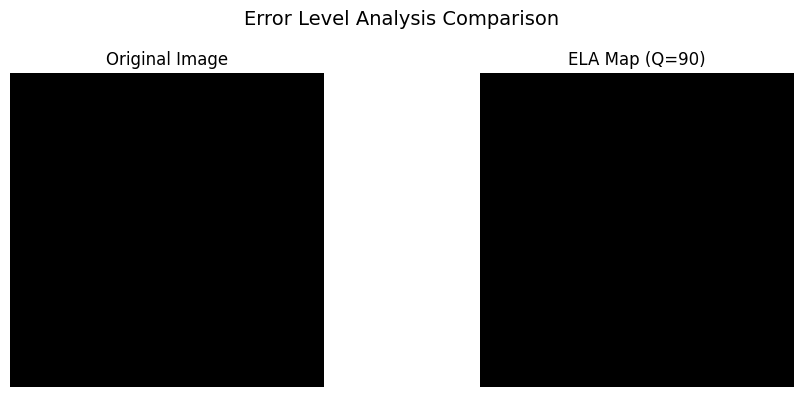

In [3]:
# ============================================================
# 2.1 Visualize ELA on a Sample Image
# ============================================================

# Find a sample authentic image (check multiple extensions)
au_path = os.path.join(DATASET_PATH, 'Au')
print(f'Looking for sample images in: {au_path}')

# List what's actually in the directory
all_au_files = os.listdir(au_path)
print(f'  Files found: {len(all_au_files)}')
if all_au_files:
    extensions = set(os.path.splitext(f)[1].lower() for f in all_au_files)
    print(f'  Extensions: {extensions}')

sample_files = [f for f in all_au_files
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.bmp'))][:1]

if sample_files:
    sample_path = os.path.join(au_path, sample_files[0])
    original = Image.open(sample_path).convert('RGB').resize(IMAGE_SIZE)
    ela = image_to_ela(sample_path, ELA_QUALITY)
    if ela is not None:
        ela = ela.resize(IMAGE_SIZE)
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(original)
        axes[0].set_title('Original Image')
        axes[0].axis('off')
        axes[1].imshow(ela)
        axes[1].set_title(f'ELA Map (Q={ELA_QUALITY})')
        axes[1].axis('off')
        plt.suptitle('Error Level Analysis Comparison', fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        print(f'  ELA conversion failed for {sample_files[0]}')
else:
    print('No sample images found.')

---

## 3. Dataset Loading

Load images from the CASIA 2.0 dataset and convert each to its ELA representation.

**Labels:**
- **Authentic (Au)** = 1
- **Tampered (Tp)** = 0

The dataset is expected to have this structure:
```
CASIA2/
  +-- Au/   (authentic images)
  +-- Tp/   (tampered images)
```

In [4]:
# ============================================================
# 3. DATASET LOADING
# ============================================================

X = []  # ELA-converted images (flattened, normalized)
Y = []  # Labels: 1 = authentic, 0 = tampered

# --- Load Authentic images ---
au_path = os.path.join(DATASET_PATH, 'Au')
print(f'Loading authentic images from: {au_path}')

au_count = 0
for dirname, _, filenames in os.walk(au_path):
    for filename in filenames:
        if filename.lower().endswith(SUPPORTED_EXTENSIONS):
            full_path = os.path.join(dirname, filename)
            img = prepare_image(full_path)
            if img is not None:
                X.append(img)
                Y.append(1)  # Authentic
                au_count += 1
            if au_count % 1000 == 0 and au_count > 0:
                print(f'  Processed {au_count} authentic images...')

print(f'  Total authentic: {au_count}')

# --- Load Tampered images ---
tp_path = os.path.join(DATASET_PATH, 'Tp')
print(f'\nLoading tampered images from: {tp_path}')

tp_count = 0
for dirname, _, filenames in os.walk(tp_path):
    for filename in filenames:
        if filename.lower().endswith(SUPPORTED_EXTENSIONS):
            full_path = os.path.join(dirname, filename)
            img = prepare_image(full_path)
            if img is not None:
                X.append(img)
                Y.append(0)  # Tampered
                tp_count += 1
            if tp_count % 1000 == 0 and tp_count > 0:
                print(f'  Processed {tp_count} tampered images...')

print(f'  Total tampered: {tp_count}')

# --- Shuffle multiple times for good mixing ---
for i in range(10):
    X, Y = shuffle(X, Y, random_state=i)

# --- Convert to numpy arrays ---
X = np.array(X)
Y = to_categorical(Y, 2)  # One-hot encoding: [tampered, authentic]
X = X.reshape(-1, IMAGE_SIZE[0], IMAGE_SIZE[1], 3)

# --- Dataset statistics ---
print(f'\n{"="*50}')
print(f'DATASET SUMMARY')
print(f'{"="*50}')
print(f'Total images:    {len(X)}')
print(f'  Authentic:     {au_count}')
print(f'  Tampered:      {tp_count}')
print(f'  Ratio (Au/Tp): {au_count/tp_count:.2f}')
print(f'X shape:         {X.shape}')
print(f'Y shape:         {Y.shape}')
print(f'X dtype:         {X.dtype}')
print(f'X range:         [{X.min():.2f}, {X.max():.2f}]')

Loading authentic images from: /kaggle/input/datasets/sagnikkayalcse52/casia-spicing-detection-localization/New folder/MASK/Au
  Processed 1000 authentic images...
  Processed 2000 authentic images...
  Processed 3000 authentic images...
  Processed 4000 authentic images...
  Processed 5000 authentic images...
  Processed 6000 authentic images...
  Processed 7000 authentic images...
  Total authentic: 7491

Loading tampered images from: /kaggle/input/datasets/sagnikkayalcse52/casia-spicing-detection-localization/New folder/MASK/Tp
  Processed 1000 tampered images...
  Processed 2000 tampered images...
  Processed 3000 tampered images...
  Processed 4000 tampered images...
  Processed 5000 tampered images...
  Total tampered: 5123

DATASET SUMMARY
Total images:    12614
  Authentic:     7491
  Tampered:      5123
  Ratio (Au/Tp): 1.46
X shape:         (12614, 150, 150, 3)
Y shape:         (12614, 2)
X dtype:         float64
X range:         [0.00, 0.76]


---

## 4. Train / Validation / Test Split

Split the dataset into three non-overlapping subsets:
- **80% Training** --- model learns from this data
- **10% Validation** --- used for monitoring during training
- **10% Test** --- final held-out evaluation

In [5]:
# ============================================================
# 4. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# First split: 80% train, 20% rest
X_train, X_rest, Y_train, Y_rest = train_test_split(
    X, Y, test_size=0.2, random_state=SEED, stratify=np.argmax(Y, axis=1)
)

# Second split: 50/50 of the 20% rest -> 10% val, 10% test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_rest, Y_rest, test_size=0.5, random_state=SEED, stratify=np.argmax(Y_rest, axis=1)
)

# Free memory
del X, Y, X_rest, Y_rest

print(f'{"="*50}')
print(f'DATA SPLIT')
print(f'{"="*50}')
print(f'Training:   {X_train.shape[0]:>6} images  | X: {X_train.shape}  Y: {Y_train.shape}')
print(f'Validation: {X_val.shape[0]:>6} images  | X: {X_val.shape}  Y: {Y_val.shape}')
print(f'Test:       {X_test.shape[0]:>6} images  | X: {X_test.shape}  Y: {Y_test.shape}')
print(f'{"="*50}')

# Class distribution check
train_labels = np.argmax(Y_train, axis=1)
print(f'\nTraining class distribution:')
print(f'  Tampered (0): {np.sum(train_labels == 0)}')
print(f'  Authentic (1): {np.sum(train_labels == 1)}')

DATA SPLIT
Training:    10091 images  | X: (10091, 150, 150, 3)  Y: (10091, 2)
Validation:   1261 images  | X: (1261, 150, 150, 3)  Y: (1261, 2)
Test:         1262 images  | X: (1262, 150, 150, 3)  Y: (1262, 2)

Training class distribution:
  Tampered (0): 4098
  Authentic (1): 5993


---

## 5. CNN Architecture

A lightweight CNN designed for ELA-based tampering detection.

### Model Design

| Layer | Type | Output Shape | Parameters |
|-------|------|-------------|------------|
| 1 | Conv2D(32, 5x5, relu) | 146x146x32 | 2,432 |
| 2 | Conv2D(32, 5x5, relu) | 142x142x32 | 25,632 |
| 3 | MaxPool2D(2x2) | 71x71x32 | 0 |
| 4 | Dropout(0.25) | 71x71x32 | 0 |
| 5 | Flatten | 161,312 | 0 |
| 6 | Dense(150, relu) | 150 | 24,196,950 |
| 7 | Dropout(0.5) | 150 | 0 |
| 8 | Dense(2, sigmoid) | 2 | 302 |

**Design rationale:**
- Two convolutional layers extract local ELA patterns (compression artifact features)
- MaxPooling reduces spatial dimensions and provides translation invariance
- Dropout prevents overfitting (0.25 after convolutions, 0.5 after dense)
- Final sigmoid outputs probability for each class

In [6]:
# ============================================================
# 5. CNN MODEL ARCHITECTURE
# ============================================================

def build_model(input_shape=(150, 150, 3), num_classes=2):
    """
    Build the CNN model for ELA-based tampering detection.

    Architecture:
        Conv2D(32, 5x5) -> Conv2D(32, 5x5) -> MaxPool(2x2) ->
        Dropout(0.25) -> Flatten -> Dense(150) -> Dropout(0.5) -> Dense(2)

    Args:
        input_shape: Input image dimensions (H, W, C)
        num_classes: Number of output classes

    Returns:
        Compiled Keras Sequential model
    """
    model = Sequential([
        Conv2D(32, kernel_size=(5, 5), padding='valid', activation='relu',
               input_shape=input_shape),
        Conv2D(32, kernel_size=(5, 5), padding='valid', activation='relu'),
        MaxPool2D(pool_size=(2, 2)),
        Dropout(0.25),
        Flatten(),
        Dense(150, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='sigmoid'),
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
    )

    return model


model = build_model(
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    num_classes=2
)

model.summary()
print(f'\nOptimizer:     Adam (lr={LEARNING_RATE})')
print(f'Loss:          binary_crossentropy')
print(f'Metrics:       accuracy, precision, recall')

I0000 00:00:1773555492.101249     113 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 146, 146, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 142, 142, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 71, 71, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 71, 71, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 161312)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 150)            │    24,196,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           302 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,225,316 (92.41 MB)

 Trainable params: 24,225,316 (92.41 MB)

 Non-trainable params: 0 (0.00 B)


Optimizer:     Adam (lr=0.0001)
Loss:          binary_crossentropy
Metrics:       accuracy, precision, recall


---

## 6. Model Training

Train the CNN with the following configuration:

| Parameter | Value |
|-----------|-------|
| Batch size | 8 |
| Epochs | 40 |
| Optimizer | Adam (lr=0.0001) |
| Loss | Binary crossentropy |
| Validation | 10% held-out split |

In [7]:
# ============================================================
# 6. MODEL TRAINING
# ============================================================

print(f'Training configuration:')
print(f'  Batch size: {BATCH_SIZE}')
print(f'  Epochs:     {EPOCHS}')
print(f'  Train:      {len(X_train)} images')
print(f'  Val:        {len(X_val)} images')
print(f'{"="*60}')

history = model.fit(
    X_train, Y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, Y_val),
    verbose=1
)

print(f'\n{"="*60}')
print(f'Training complete.')
print(f'  Final train accuracy: {history.history["accuracy"][-1]:.4f}')
print(f'  Final val accuracy:   {history.history["val_accuracy"][-1]:.4f}')

Training configuration:
  Batch size: 8
  Epochs:     40
  Train:      10091 images
  Val:        1261 images
Epoch 1/40


I0000 00:00:1773555502.494512     172 service.cc:152] XLA service 0x7978ac006030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773555502.494550     172 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773555502.886470     172 cuda_dnn.cc:529] Loaded cuDNN version 91002


  11/1262 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.5206 - loss: 0.6923 - precision: 0.6029 - recall: 0.5642

I0000 00:00:1773555506.678666     172 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1262/1262 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.9527 - loss: 0.1488 - precision: 0.9527 - recall: 0.9570 - val_accuracy: 0.9984 - val_loss: 0.0060 - val_precision: 0.9984 - val_recall: 0.9984
Epoch 2/40
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.9994 - loss: 0.0067 - precision: 0.9989 - recall: 0.9993 - val_accuracy: 0.9984 - val_loss: 0.0055 - val_precision: 0.9984 - val_recall: 0.9984
Epoch 3/40
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.9995 - loss: 0.0065 - precision: 0.9995 - recall: 0.9995 - val_accuracy: 0.9984 - val_loss: 0.0066 - val_precision: 0.9984 - val_recall: 0.9984
Epoch 4/40
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.9995 - loss: 0.0058 - precision: 0.9995 - recall: 0.9995 - val_accuracy: 0.9984 - val_loss: 0.0085 - val_precision: 0.9984 - val_recall: 0.9984
Epoch 5/40
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.9995 - loss: 0.0058 - precision: 0.9995 - recall: 0.9995 - val_accuracy: 0.9984 - val

---

## 7. Evaluation

Evaluate the trained model on the held-out test set to get unbiased performance estimates.

In [8]:
# ============================================================
# 7. MODEL EVALUATION
# ============================================================

# Keras built-in evaluation
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(
    X_test, Y_test, verbose=0
)

# Predictions for sklearn metrics
y_pred_probs = model.predict(X_test, verbose=0)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(Y_test, axis=1)

# Compute F1 score
test_f1 = f1_score(y_true_labels, y_pred_labels, average='macro')

# Full classification report
print(f'{"="*60}')
print(f'TEST SET EVALUATION')
print(f'{"="*60}')
print(f'  Loss:      {test_loss:.4f}')
print(f'  Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print(f'  Precision: {test_precision:.4f}')
print(f'  Recall:    {test_recall:.4f}')
print(f'  F1 Score:  {test_f1:.4f}')
print(f'{"="*60}')

print(f'\nDetailed Classification Report:')
print(classification_report(
    y_true_labels, y_pred_labels,
    target_names=['Tampered', 'Authentic'],
    digits=4
))

TEST SET EVALUATION
  Loss:      0.0000
  Accuracy:  1.0000 (100.00%)
  Precision: 1.0000
  Recall:    1.0000
  F1 Score:  1.0000

Detailed Classification Report:
              precision    recall  f1-score   support

    Tampered     1.0000    1.0000    1.0000       513
   Authentic     1.0000    1.0000    1.0000       749

    accuracy                         1.0000      1262
   macro avg     1.0000    1.0000    1.0000      1262
weighted avg     1.0000    1.0000    1.0000      1262



### Confusion Matrix

Visualize the model's classification performance across both classes.

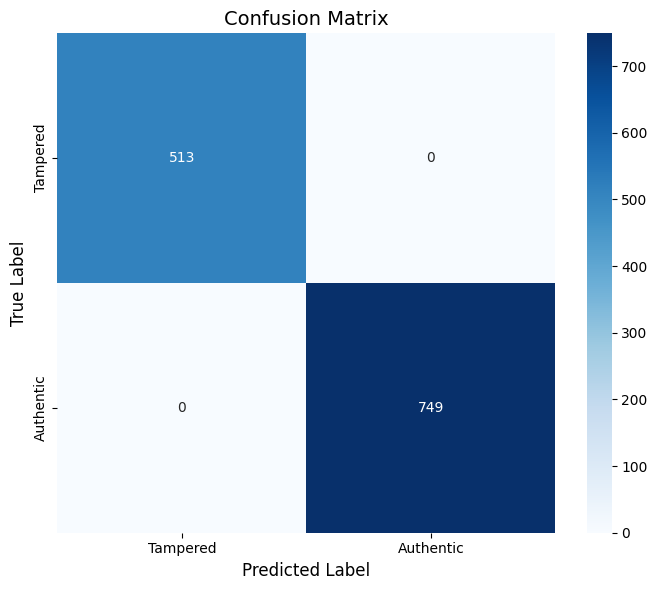

True Negatives (Tampered correct):  513
False Positives (Au predicted Tp):  0
False Negatives (Tp predicted Au):  0
True Positives (Authentic correct): 749


In [9]:
# ============================================================
# 7.1 Confusion Matrix
# ============================================================

cm = confusion_matrix(y_true_labels, y_pred_labels)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Tampered', 'Authentic'],
            yticklabels=['Tampered', 'Authentic'])
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# Print confusion matrix values
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives (Tampered correct):  {tn}')
print(f'False Positives (Au predicted Tp):  {fp}')
print(f'False Negatives (Tp predicted Au):  {fn}')
print(f'True Positives (Authentic correct): {tp}')

---

## 8. Training Visualization

Plot training and validation curves to assess model convergence and overfitting.

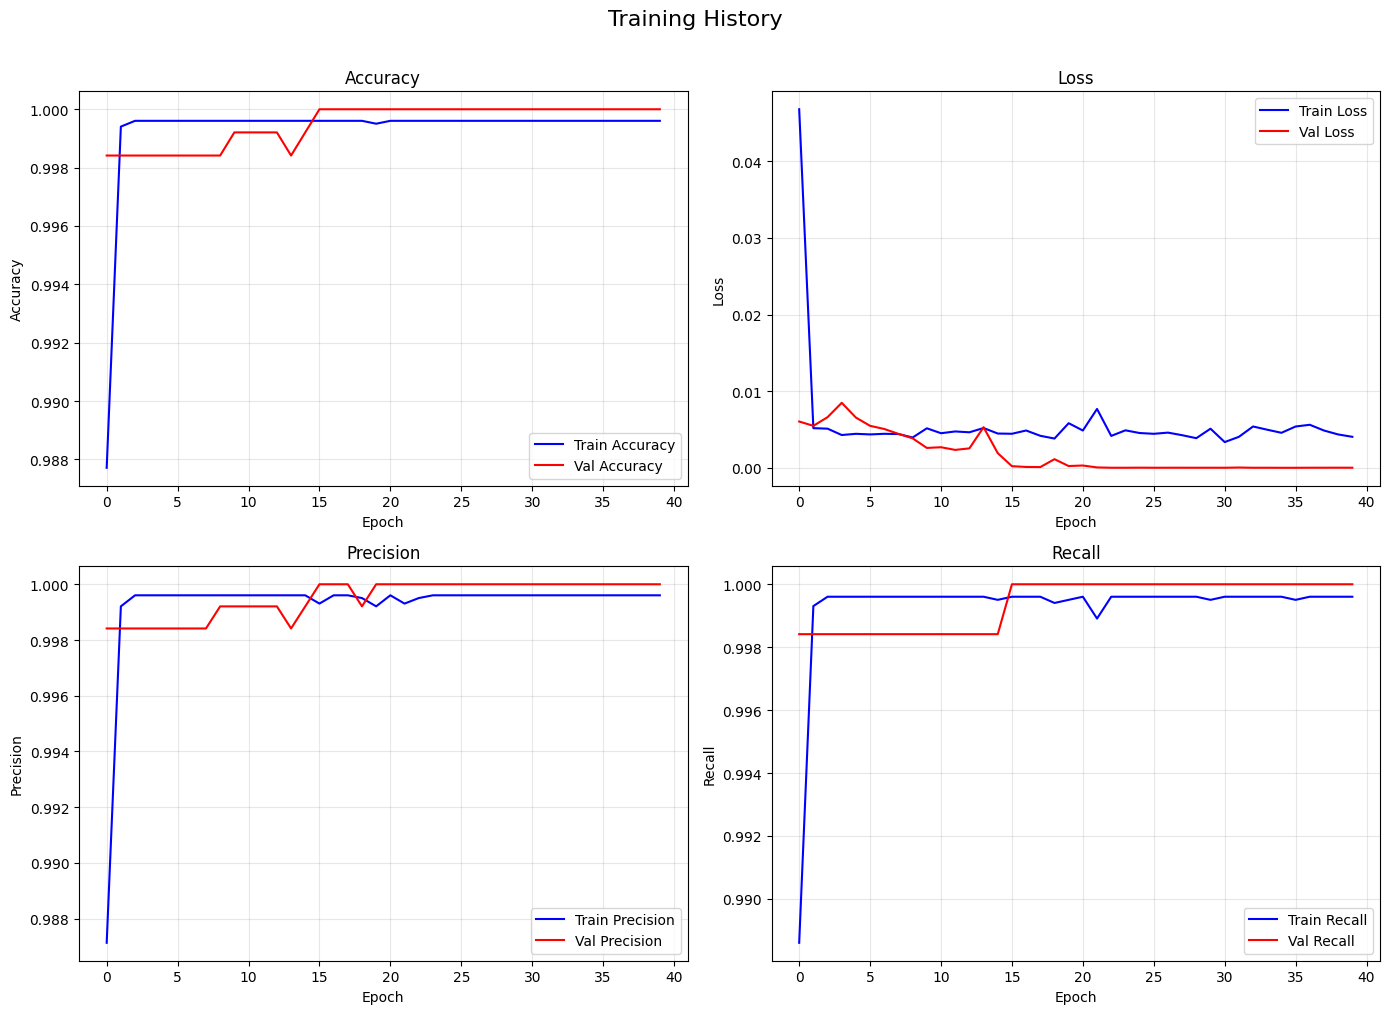

In [10]:
# ============================================================
# 8. TRAINING CURVES
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Accuracy ---
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', color='red')
axes[0, 0].set_title('Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# --- Loss ---
axes[0, 1].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0, 1].plot(history.history['val_loss'], label='Val Loss', color='red')
axes[0, 1].set_title('Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# --- Precision ---
axes[1, 0].plot(history.history['precision'], label='Train Precision', color='blue')
axes[1, 0].plot(history.history['val_precision'], label='Val Precision', color='red')
axes[1, 0].set_title('Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# --- Recall ---
axes[1, 1].plot(history.history['recall'], label='Train Recall', color='blue')
axes[1, 1].plot(history.history['val_recall'], label='Val Recall', color='red')
axes[1, 1].set_title('Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---

## 9. Model Saving

Save the trained model in two formats:
- **HDF5 (.h5)** --- full model (architecture + weights + optimizer state)
- **JSON (.json)** --- architecture only (for deployment flexibility)

In [11]:
# ============================================================
# 9. SAVE MODEL
# ============================================================

# Save full model (architecture + weights + optimizer)
model_h5_path = 'casia2_ela_cnn_model.h5'
model.save(model_h5_path)
print(f'Model saved: {model_h5_path}')
print(f'  File size: {os.path.getsize(model_h5_path) / 1e6:.1f} MB')

# Save architecture as JSON
model_json_path = 'casia2_ela_cnn_model.json'
model_json = model.to_json()
with open(model_json_path, 'w') as f:
    f.write(model_json)
print(f'Architecture saved: {model_json_path}')

Model saved: casia2_ela_cnn_model.h5
  File size: 290.7 MB
Architecture saved: casia2_ela_cnn_model.json


---

## 10. Single Image Prediction

A utility function to predict whether a single new image is authentic or tampered.

In [12]:
# ============================================================
# 10. SINGLE IMAGE PREDICTION
# ============================================================

def predict_image(image_path, model, image_size=IMAGE_SIZE, ela_quality=ELA_QUALITY):
    """
    Predict whether a single image is authentic or tampered.

    Args:
        image_path: Path to the image file
        model: Trained Keras model
        image_size: Expected input size (H, W)
        ela_quality: ELA JPEG quality

    Returns:
        dict: Prediction results with label, confidence, and probabilities
    """
    # Convert to ELA
    ela = image_to_ela(image_path, ela_quality)
    if ela is None:
        return {'error': f'Could not process {image_path}'}

    # Preprocess
    ela_resized = ela.resize(image_size)
    ela_array = np.array(ela_resized) / 255.0
    ela_input = ela_array.reshape(1, image_size[0], image_size[1], 3)

    # Predict
    prediction = model.predict(ela_input, verbose=0)[0]
    predicted_class = np.argmax(prediction)
    confidence = prediction[predicted_class]

    labels = {0: 'Tampered', 1: 'Authentic'}

    return {
        'label': labels[predicted_class],
        'confidence': float(confidence),
        'tampered_prob': float(prediction[0]),
        'authentic_prob': float(prediction[1]),
    }


def visualize_prediction(image_path, model):
    """Predict and visualize a single image with its ELA map."""
    result = predict_image(image_path, model)
    if 'error' in result:
        print(result['error'])
        return

    original = Image.open(image_path).convert('RGB').resize(IMAGE_SIZE)
    ela = image_to_ela(image_path, ELA_QUALITY).resize(IMAGE_SIZE)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(original)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(ela)
    axes[1].set_title(f'ELA Map (Q={ELA_QUALITY})')
    axes[1].axis('off')

    color = 'green' if result['label'] == 'Authentic' else 'red'
    plt.suptitle(
        f"Prediction: {result['label']} ({result['confidence']:.1%})",
        fontsize=14, color=color, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    print(f"  Tampered probability:  {result['tampered_prob']:.4f}")
    print(f"  Authentic probability: {result['authentic_prob']:.4f}")


# --- Example usage (uncomment and set path to test) ---
# visualize_prediction('/path/to/test/image.jpg', model)
print('Prediction functions ready.')
print('Usage: visualize_prediction(image_path, model)')

Prediction functions ready.
Usage: visualize_prediction(image_path, model)


---

## 11. Results Summary

In [13]:
# ============================================================
# 11. RESULTS SUMMARY
# ============================================================

print(f'{"="*60}')
print(f'  FINAL RESULTS SUMMARY')
print(f'{"="*60}')
print()
print(f'Model:          CNN (Conv2D x2 + Dense)')
print(f'Input:          ELA (Q={ELA_QUALITY}, {IMAGE_SIZE[0]}x{IMAGE_SIZE[1]})')
print(f'Dataset:        CASIA 2.0')
print(f'Split:          80/10/10 (train/val/test)')
print(f'Training:       {EPOCHS} epochs, batch={BATCH_SIZE}')
print()
print(f'Test Metrics:')
print(f'  Accuracy:     {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print(f'  Precision:    {test_precision:.4f}')
print(f'  Recall:       {test_recall:.4f}')
print(f'  F1 Score:     {test_f1:.4f}')
print(f'  Loss:         {test_loss:.4f}')
print()
print(f'Saved artifacts:')
print(f'  Model:        {model_h5_path}')
print(f'  Architecture: {model_json_path}')
print(f'{"="*60}')

  FINAL RESULTS SUMMARY

Model:          CNN (Conv2D x2 + Dense)
Input:          ELA (Q=90, 150x150)
Dataset:        CASIA 2.0
Split:          80/10/10 (train/val/test)
Training:       40 epochs, batch=8

Test Metrics:
  Accuracy:     1.0000 (100.00%)
  Precision:    1.0000
  Recall:       1.0000
  F1 Score:     1.0000
  Loss:         0.0000

Saved artifacts:
  Model:        casia2_ela_cnn_model.h5
  Architecture: casia2_ela_cnn_model.json
